In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns', None)

In [9]:
import pandas as pd

file_path = "student_data1.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
display(df.head())
print(df.info())

Shape: (10000, 20)


,Gender,Age,Semester,Branch,Difficulty_Level,Attendance (%),Midterm_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Study_Hours_per_Week,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level,Sleep_Hours_per_Night,Final_Score,Grade,Pass/Fail
0,Male,23,6,CSE,Hard,52.945086,42.60,47.20,27.25,4.970665,45.28,27.702422,Yes,NaN,Mid,5.46,8.28,52.93,C,Pass
1,Female,19,2,CSE,Easy,NaN,62.31,49.93,40.11,5.159091,49.82,23.138946,Yes,Secondary,Mid,4.29,9.21,59.42,E,Pass
2,Male,18,2,Civil,Easy,74.524728,61.30,47.75,48.17,3.014923,45.46,21.235462,Yes,Primary,Mid,4.25,6.75,56.59,C,Pass
3,Male,18,3,CSE,Moderate,67.977237,52.35,45.15,28.36,4.303704,39.93,19.441623,Yes,NaN,Low,5.69,6.84,54.40,C,Pass
4,Female,22,5,CSE,Easy,61.048711,56.86,38.82,34.48,4.877667,27.46,14.898586,Yes,Graduate,Low,4.18,9.28,56.73,C,Pass


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   10000 non-null  object 
 1   Age                      10000 non-null  int64  
 2   Semester                 10000 non-null  int64  
 3   Branch                   10000 non-null  object 
 4   Difficulty_Level         10000 non-null  object 
 5   Attendance (%)           9397 non-null   float64
 6   Midterm_Score            10000 non-null  float64
 7   Assignments_Avg          10000 non-null  float64
 8   Quizzes_Avg              10000 non-null  float64
 9   Participation_Score      9131 non-null   float64
 10  Projects_Score           10000 non-null  float64
 11  Study_Hours_per_Week     9197 non-null   float64
 12  Internet_Access_at_Home  10000 non-null  object 
 13  Parent_Education_Level   7868 non-null   object 
 14  Family_Income_Level    

In [3]:

from sklearn.impute import SimpleImputer

df = pd.read_csv("student_data1.csv")

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print(df.isnull().sum())

Gender                     0
Age                        0
Semester                   0
Branch                     0
Difficulty_Level           0
Attendance (%)             0
Midterm_Score              0
Assignments_Avg            0
Quizzes_Avg                0
Participation_Score        0
Projects_Score             0
Study_Hours_per_Week       0
Internet_Access_at_Home    0
Parent_Education_Level     0
Family_Income_Level        0
Stress_Level               0
Sleep_Hours_per_Night      0
Final_Score                0
Grade                      0
Pass/Fail                  0
dtype: int64


In [4]:
float_cols = df.select_dtypes(include=['float64']).columns
df[float_cols] = df[float_cols].astype(int)

print(df.dtypes)

Gender                     object
Age                         int64
Semester                    int64
Branch                     object
Difficulty_Level           object
Attendance (%)              int64
Midterm_Score               int64
Assignments_Avg             int64
Quizzes_Avg                 int64
Participation_Score         int64
Projects_Score              int64
Study_Hours_per_Week        int64
Internet_Access_at_Home    object
Parent_Education_Level     object
Family_Income_Level        object
Stress_Level                int64
Sleep_Hours_per_Night       int64
Final_Score                 int64
Grade                      object
Pass/Fail                  object
dtype: object


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
X = df.drop(["Final_Score","Grade","Pass/Fail"], axis=1)
y = df["Final_Score"]

num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print("Preprocessing completed")

Preprocessing completed


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

model = LinearRegression()

param_grid = {
    "fit_intercept": [True, False],
    "positive": [True, False]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Model training completed")

Best Parameters: {'fit_intercept': True, 'positive': False}
Model training completed


R2 Score: 0.885632100195113
MAE: 4.772857800503726
MSE: 36.30774115116669
RMSE: 6.0255905230248334


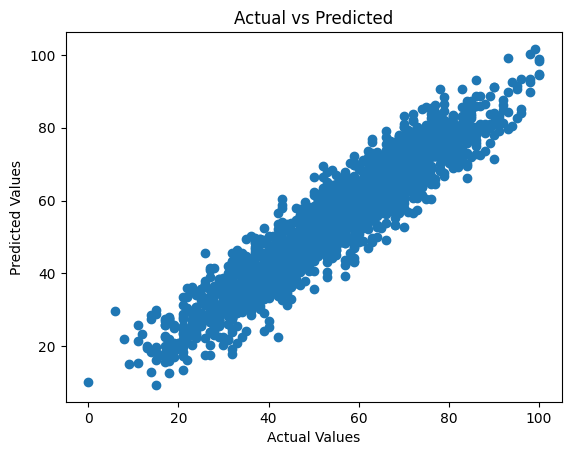

In [7]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()